In [1]:
using XLSX
using StatsPlots
using DataFrames


In [9]:
#ler o doc em xlsx
# Option 1: Skip the first row (the title row) and use row 2 as header
df = DataFrame(XLSX.readtable("pnas201907998_s5_movfsn.xlsx", "Sheet 1"; first_row=2))

Row,Family,Taxon,Age (Myrs BP),d13C,Isotope value ref.,Mass,Paleo body mass ref. (see full reference list below)
,Any,Any,Any,Any,Any,Any,Any
1,Deinotheriidae,Deinotherium bozasi,9.9,-9.5,Uno et al. 2011,9000000,Larramendi et al. 2015
2,Deinotheriidae,Deinotherium bozasi,9.9,-10.1,Uno et al. 2011,9000000,Larramendi et al. 2015
3,Deinotheriidae,Deinotherium bozasi,9.9,-11.7,Uno et al. 2011,9000000,Larramendi et al. 2015
4,Deinotheriidae,Deinotherium bozasi,9.9,-11.5,Uno et al. 2011,9000000,Larramendi et al. 2015
5,Deinotheriidae,Deinotherium bozasi,9.9,-10.7,Uno et al. 2011,9000000,Larramendi et al. 2015
6,Deinotheriidae,Deinotherium bozasi,9.9,-10,Uno et al. 2011,9000000,Larramendi et al. 2015
7,Deinotheriidae,Deinotherium bozasi,9.6,-9.8,Uno et al. 2011,9000000,Larramendi et al. 2015
8,Deinotheriidae,Deinotherium bozasi,9.6,-9.6,Uno et al. 2011,9000000,Larramendi et al. 2015
9,Deinotheriidae,Deinotherium bozasi,9.6,-9.5,Uno et al. 2011,9000000,Larramendi et al. 2015


In [10]:
df.strategy = similar(df.d13C, String)

1013-element Vector{String}:
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
   ⋮
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef

In [11]:

for i in 1:nrow(df)
    if -25 <= df.d13C[i] < -8
        df.strategy[i] = "browser"
    elseif -8 <= df.d13C[i] < 1
        df.strategy[i] = "mixed"
    elseif df.d13C[i] >= 1
        df.strategy[i] = "grazer"
    else
        df.strategy[i] = "unknown"
    end
end

In [ ]:
# df.mass_kg = df.Mass ./ 1000
# df.logmass = log10.(df.mass_kg)

1013-element Vector{Float64}:
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 ⋮
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813

In [50]:
default(
    fontfamily = "Helvetica",
    guidefont = font(18),
    tickfont = font(15),
    legendfont = font(13),
    dpi = 600
)

# ============================================================
# Plotagem aprimorada
# ============================================================
browser_color = "#1B9E77"
grazer_color  = "#D95F02"
mixed_color   = "#7570B3"

# Define os ticks desejados (somente potências inteiras de 10)
xticks_values = [0, 1, 2, 3, 4]  # eixo está em log10(massa)
xticks_labels = ["10⁰", "10¹", "10²", "10³", "10⁴"]

5-element Vector{String}:
 "10⁰"
 "10¹"
 "10²"
 "10³"
 "10⁴"

In [17]:
df.mass_kg = df.Mass ./ 1000
df.logmass = log10.(df.mass_kg)

1013-element Vector{Float64}:
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 3.9542425094393248
 ⋮
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813
 2.1760912590556813

In [31]:
# Filter first, then extract the column as a vector
grazers = df[df.strategy .== "grazer", :logmass]
browsers = df[df.strategy .== "browser", :logmass]
mixed = df[df.strategy .== "mixed", :logmass]

p = density(grazers,
    xlabel = "Body Mass (kg)",
    ylabel = "Density",
    lw = 5,
    color = grazer_color,
    label = "Grazer",
    size = (800, 650),
    grid = false,
    framestyle = :box,
    xticks = (xticks_values, xticks_labels)
)

density!(p, browsers, lw = 5, color = browser_color, label = "Browser")
density!(p, mixed,    lw = 5, color = mixed_color,   label = "Mixed")

p

In [37]:
p = density(grazers,
    xlabel = "Body Mass (kg)",
    ylabel = "Density",
    lw = 5,
    color = grazer_color,
    label = "Grazer",
    size = (800, 650),
    grid = false,
    framestyle = :box
)
density!(p, browsers, lw=5, color=browser_color, label="Browser")
density!(p, mixed, lw=5, color=mixed_color, label="Mixed")
p

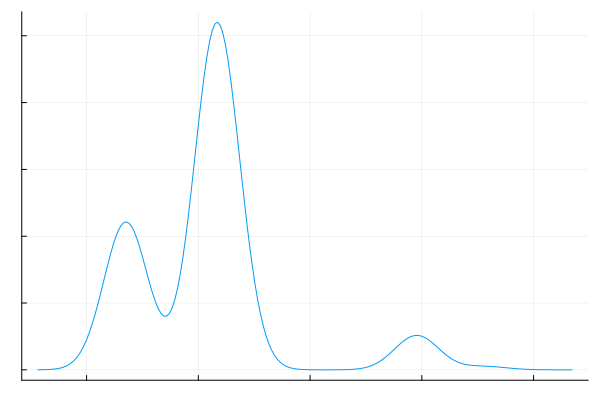

In [57]:
p = density(grazers, label="Grazer", legend=:topright)
plot!([], [], color=grazer_color, label="Grazer", lw=5)
p

In [53]:
Plots.reset_defaults()

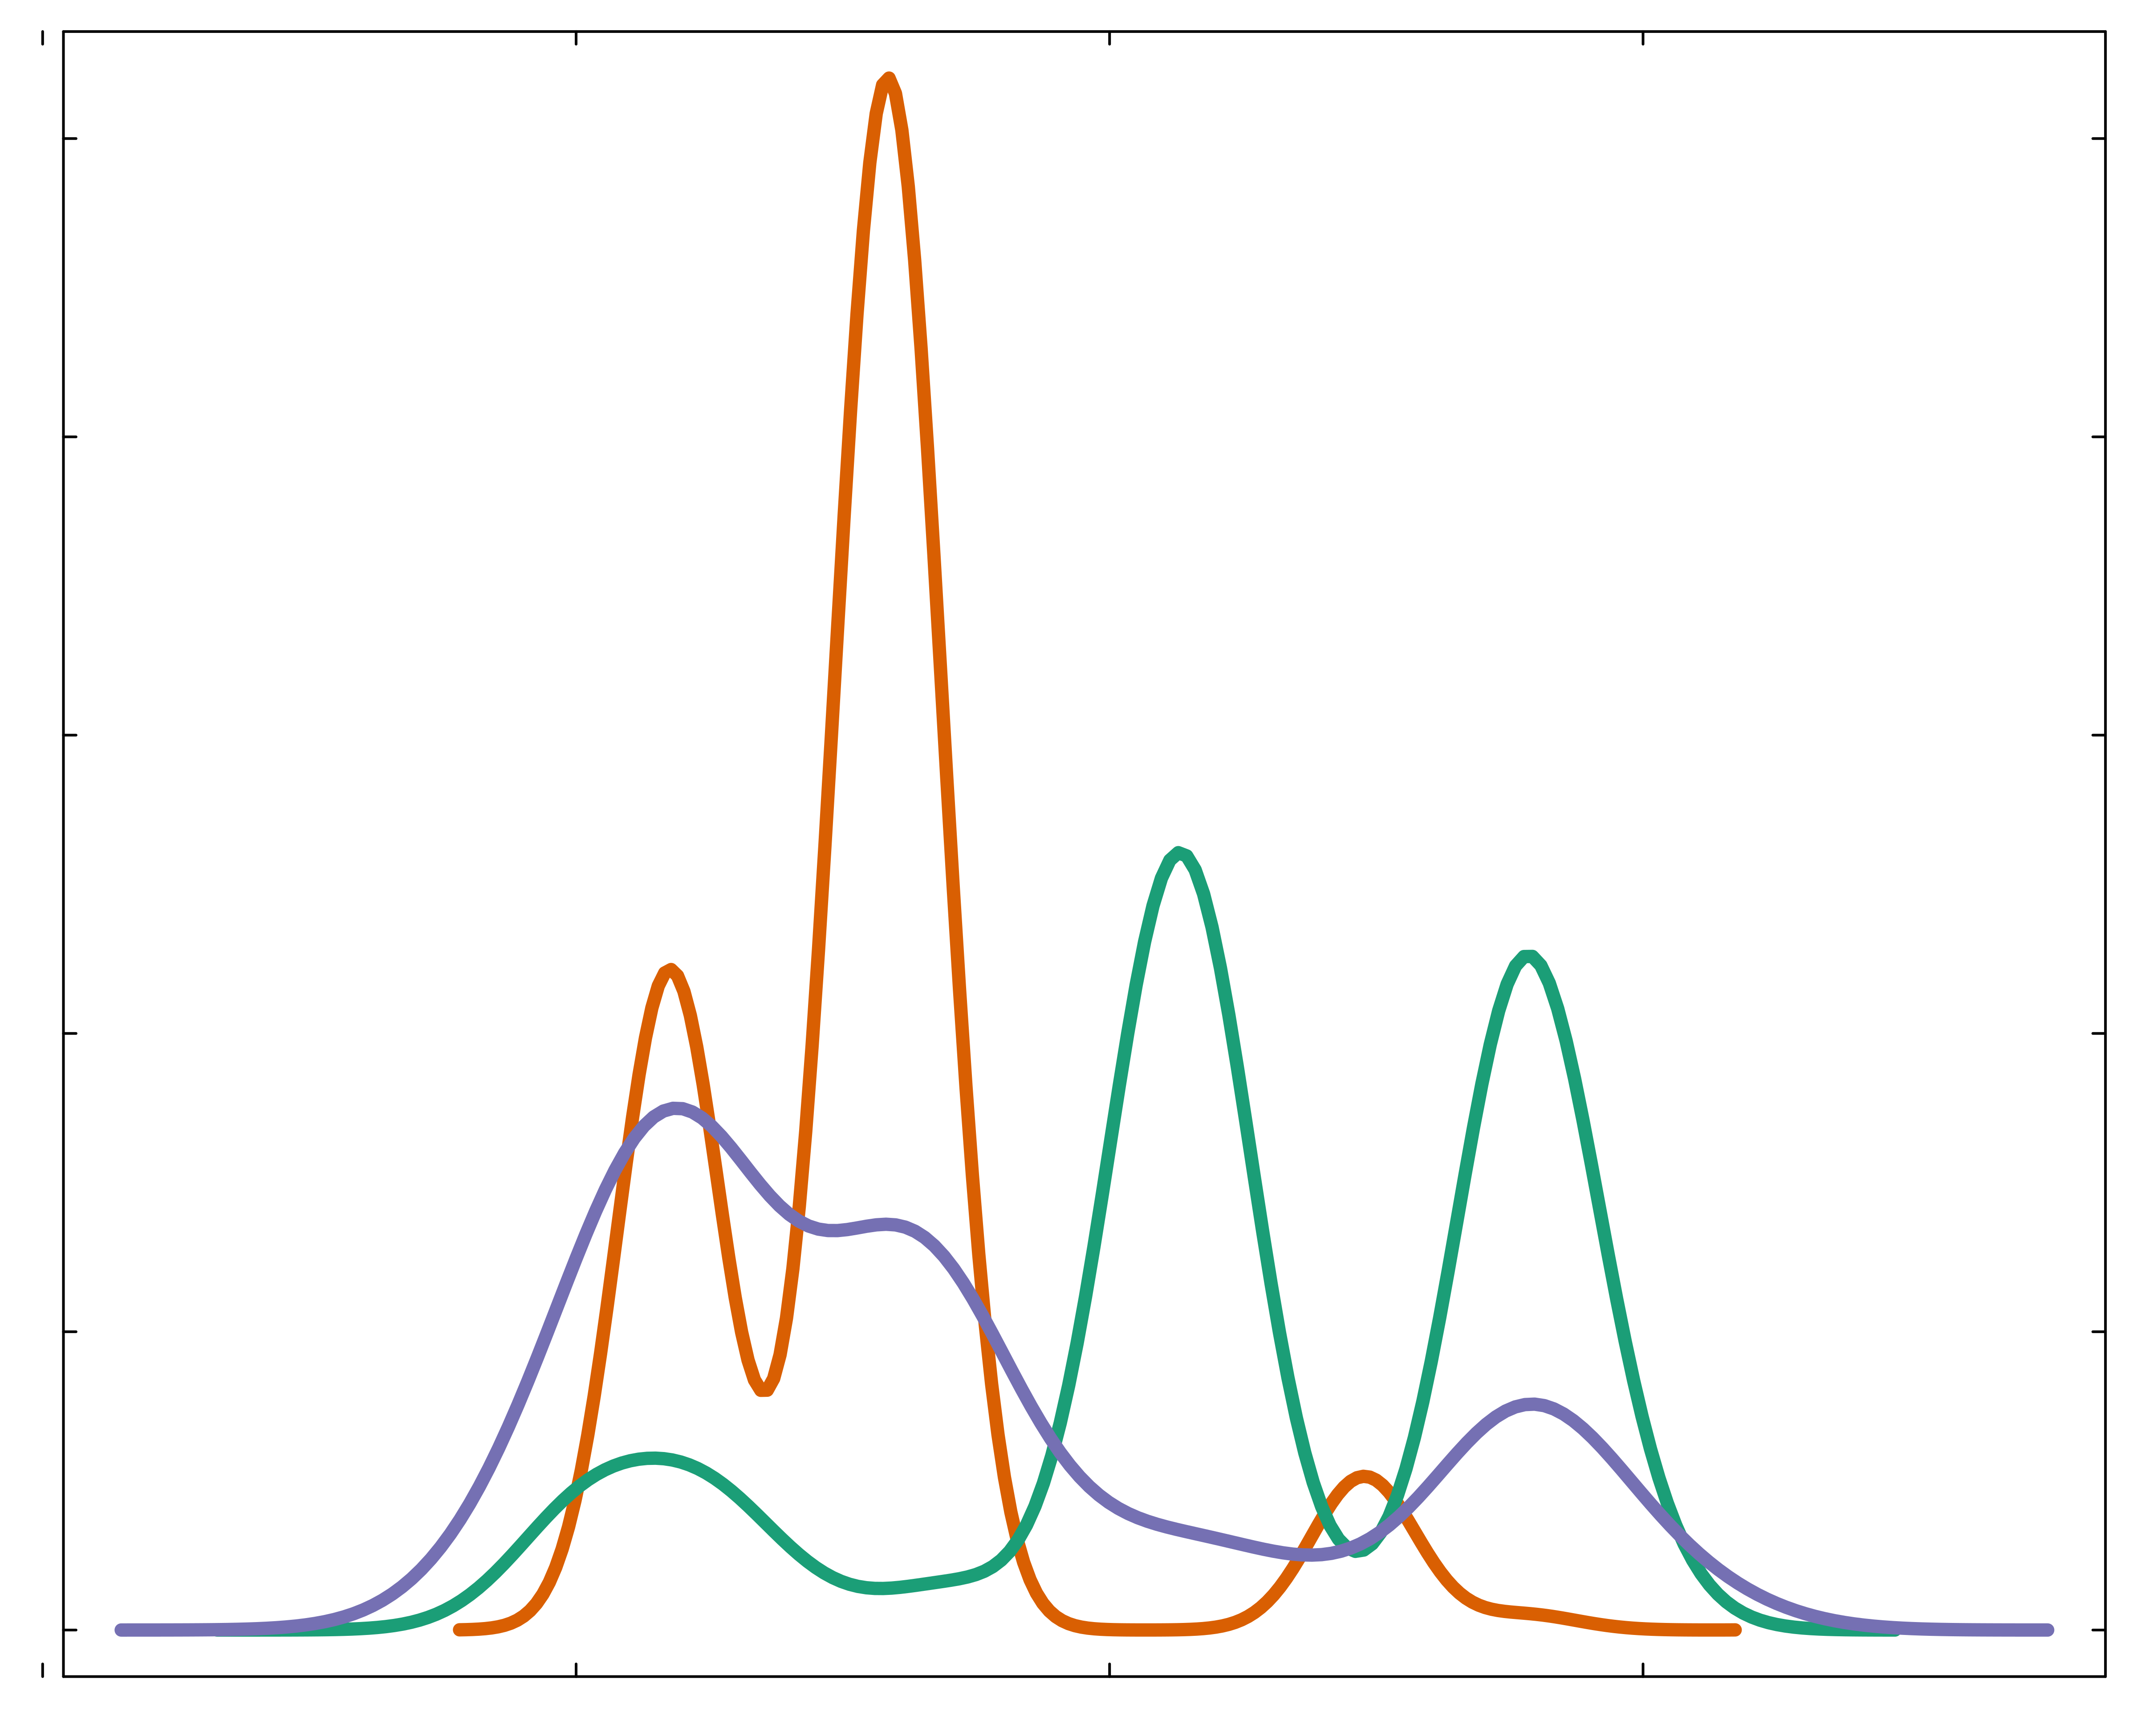

In [51]:
p = density(grazers, lw=5, color = grazer_color, size = (800,650), grid = false, framestyle = :box, label= "Grazers", xticks = (xticks_values, xticks_labels))
density!(p, browsers, lw=5, color=browser_color, label="Browser")
density!(p, mixed, lw=5, color=mixed_color, label="Mixed")

In [35]:
println(grazers)
println(length(grazers))

[3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 3.4771212547196626, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978359661681, 2.57978

In [36]:
println(any(isnan, grazers))
println(any(isinf, grazers))

false
false


In [24]:
import Pkg; Pkg.add("PlotlyJS")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Pidfile ─────────────── v1.3.0
   Installed Hiccup ──────────────── v0.2.2
   Installed PlotlyKaleido ───────── v2.3.1
   Installed AssetRegistry ───────── v0.1.1
   Installed PlotlyBase ──────────── v0.8.23
   Installed Lazy ────────────────── v0.15.1
   Installed WebIO ───────────────── v0.8.21
   Installed WebSockets ──────────── v1.6.0
   Installed Kaleido_jll ─────────── v0.2.1+0
   Installed Blink ───────────────── v0.12.9
   Installed Mustache ────────────── v1.0.21
   Installed UnPack ──────────────── v1.0.2
   Installed PlotlyJS ────────────── v0.18.17
   Installed JSExpr ──────────────── v0.5.4
   Installed FunctionalCollections ─ v0.5.0
   Installed Mux ─────────────────── v1.0.2
   Installed Parameters ──────────── v0.12.3
    Updating `~/.julia/environments/v1.11/Project.toml`
  [f0f68f2c] + PlotlyJS v0.18.17
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [

In [25]:
using Plots
plotlyjs()  # or try: gr()

WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

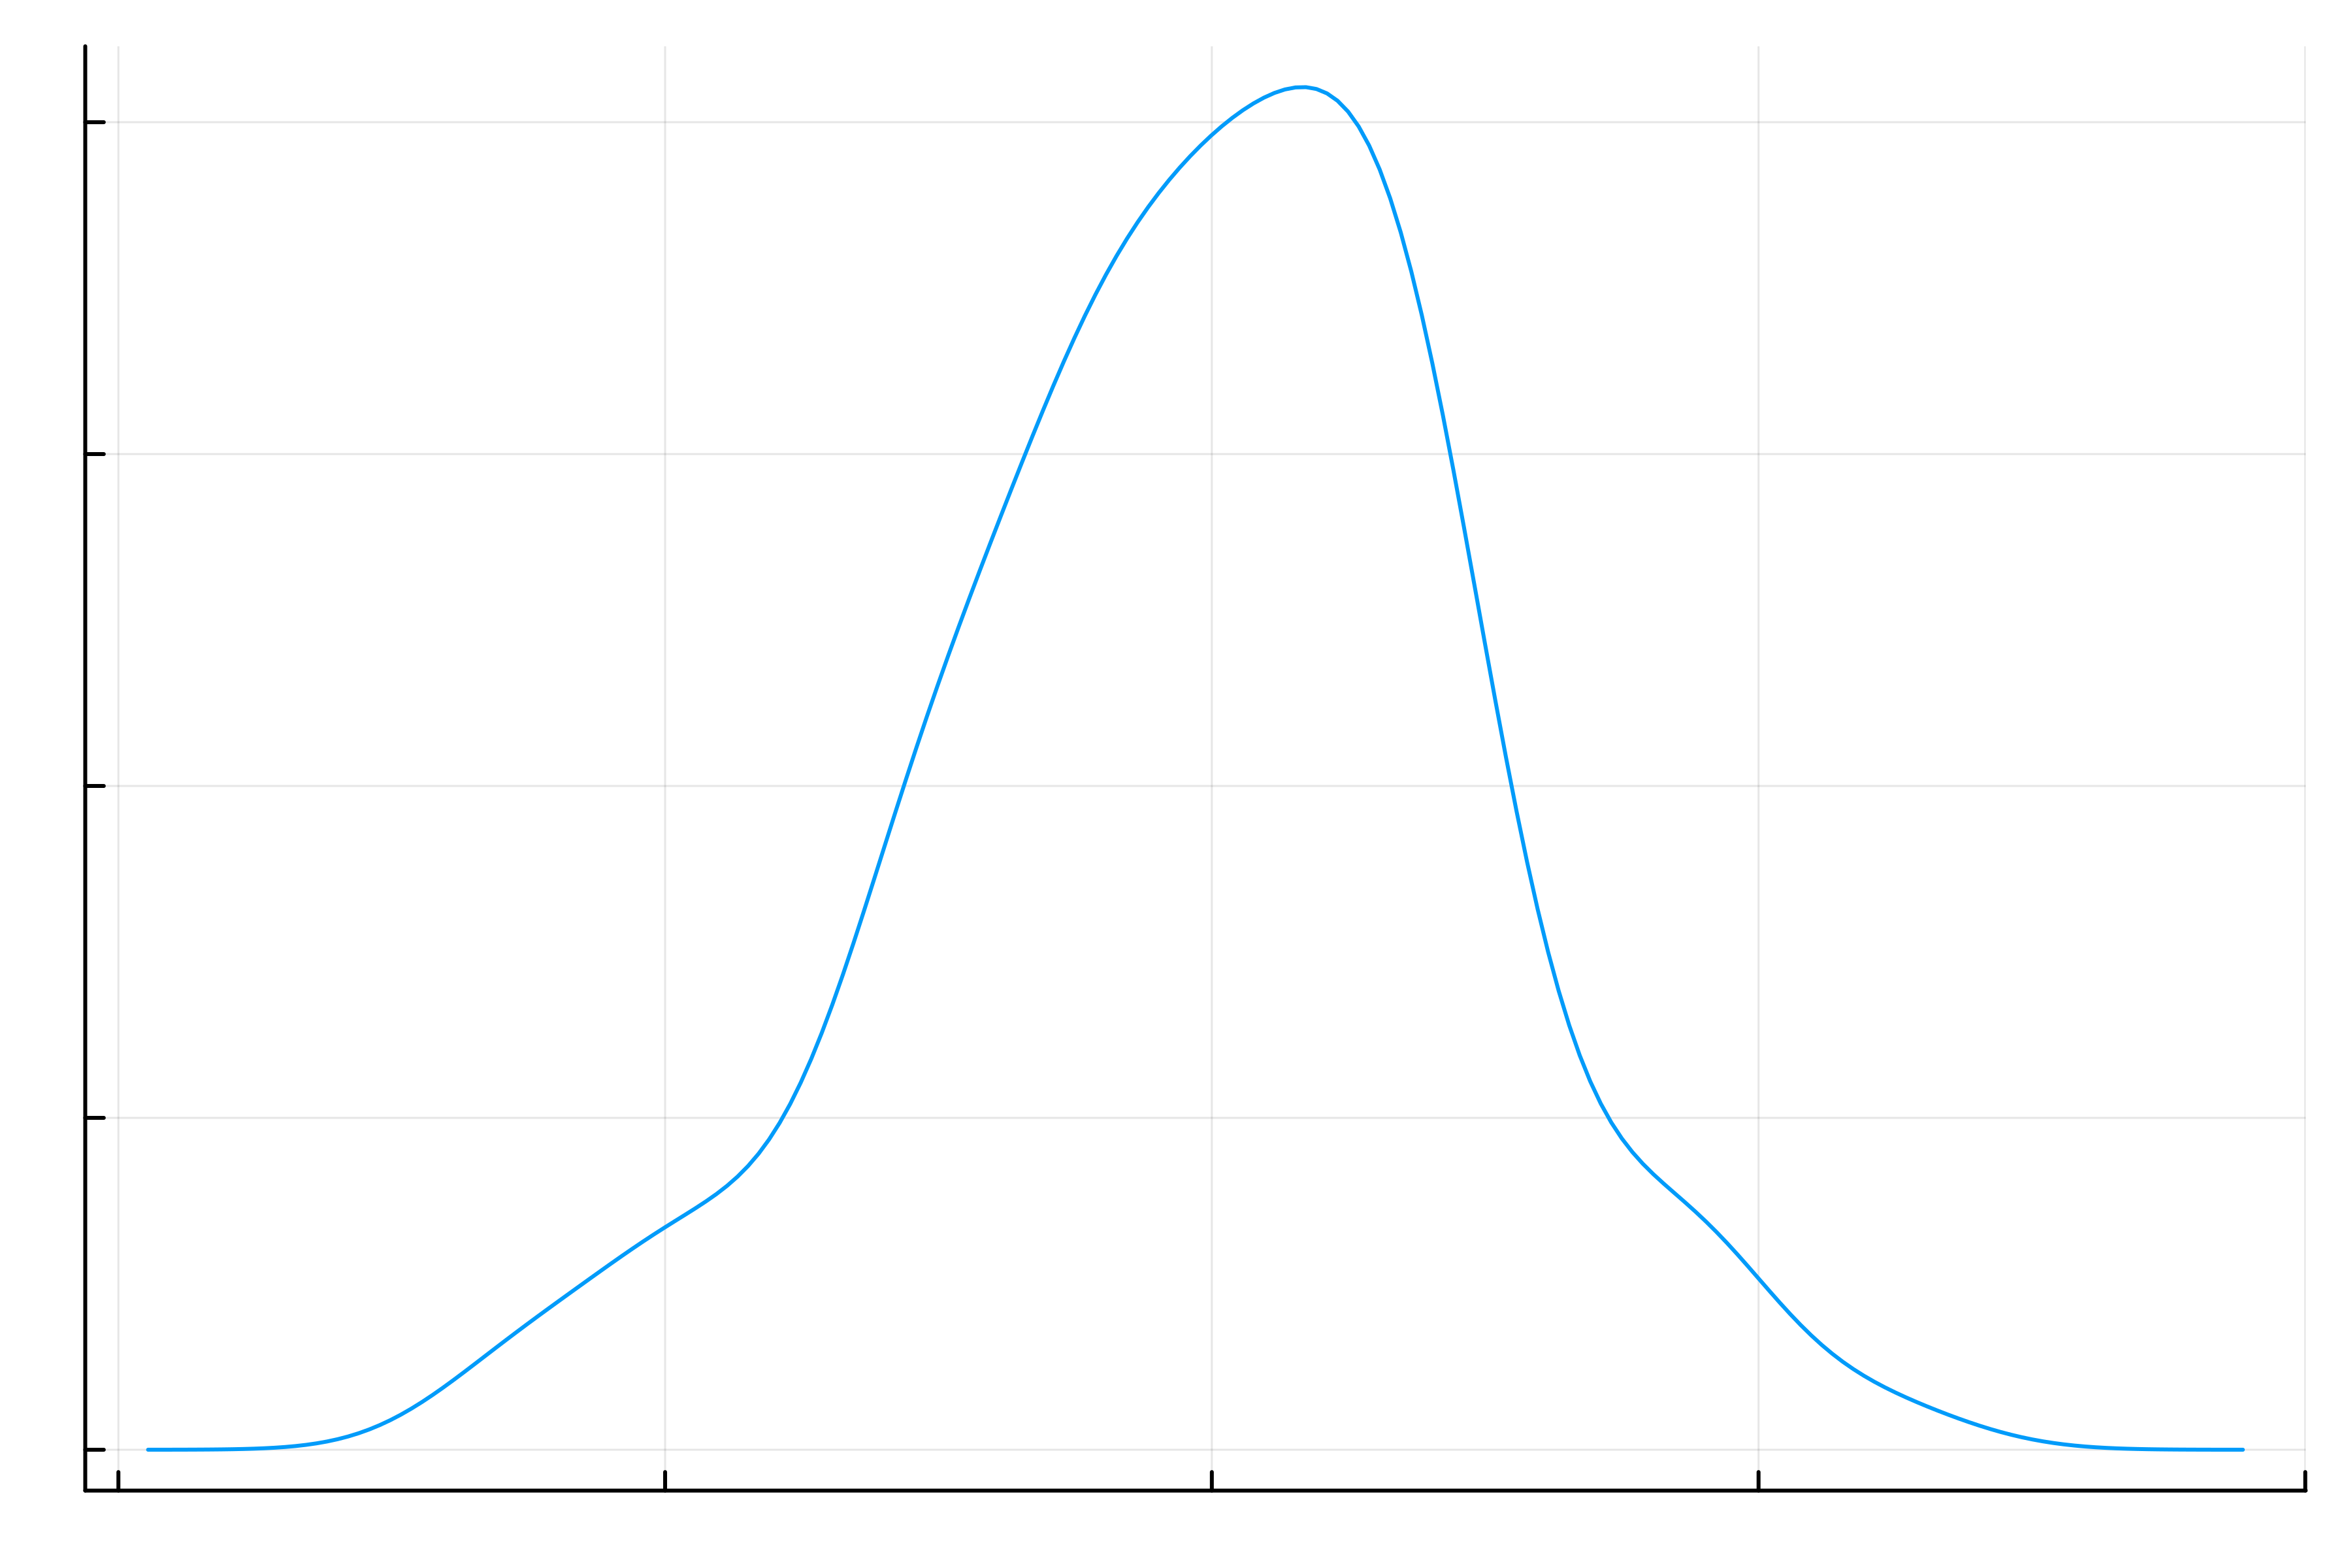

In [27]:
using StatsPlots
gr()

x = randn(100)
density(x)
